## Load in data

In [4]:
import pandas as pd

In [5]:
dataset = pd.read_parquet('../data/processed/features.parquet')
dataset.head()

,user_id,item_id,rating,timestamp,movie_title,release_date,video_release_date,imdb_url,genre_0,genre_1,...,genre_14,genre_15,genre_16,genre_17,genre_18,age,gender,occupation,zip_code,click
0,196,242,3,881250949,Kolya (1996),24-Jan-1997,NaN,http://us.imdb.com/M/title-exact?Kolya%20(1996),0,0,...,0,0,0,0,0,49,M,writer,55105,0
1,186,302,3,891717742,L.A. Confidential (1997),01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?L%2EA%2E+Conf...,0,0,...,0,0,1,0,0,39,F,executive,00000,0
2,22,377,1,878887116,Heavyweights (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?Heavyweights%...,0,0,...,0,0,0,0,0,25,M,writer,40206,0
3,244,51,2,880606923,Legends of the Fall (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?Legends%20of%...,0,0,...,1,0,0,1,1,28,M,technician,80525,0
4,166,346,1,886397596,Jackie Brown (1997),01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?imdb-title-11...,0,0,...,0,0,0,0,0,47,M,educator,55113,0


## Train The Models

### Variant A : Collaborative Filtering


For our first model, we are going to do collaborative filtering. In collaborative filtering, we recommend items to users that other similar users have also liked.

For our first baseline model we will be using KNNwithMeans which builds upon normal KNNBasic. In KNNBasic, we use the K nearest neighbours' ratings at face values, whereas 'withMeans' adjusts for user bias in terms of how they rate by centering ratings around user averages. Additionally, we are using cosine similarity as our distance metric

In [27]:
from surprise import Dataset, Reader, KNNWithMeans

# create the reader for rating
reader = Reader(rating_scale=(1, 5))

# load the dataset from the data from the previous notebook
data = Dataset.load_from_df(dataset[['user_id', 'item_id', 'rating']], reader)

# we are going to do item-based 
sim_options = {"name" : "cosine", "user_based": False}
# use KNNWithMeans algorithm for collaborative filtering
algo = KNNWithMeans(sim_options=sim_options)

In [28]:
from surprise.model_selection import train_test_split
from surprise import accuracy

trainset, testset = train_test_split(data, test_size= 0.2)

# train the algorithm on the train set
algo.fit(trainset)

# get the predictions of the test set
predictions = algo.test(testset)

Computing the cosine similarity matrix...
Done computing similarity matrix.


Now that we have the predictions we should calculate the root mean square error and mean absolute error. We are also converting the predicted ratings into a probability of that movie being clicked by the user; from this we can get the simulated CTR for variant A. We also calculate AUC which is the area under the curve indicating how well our model distinguished between classes (click / no click), getting a score of 0.774 (where 1 perfect).

In [29]:
print(f"RMSE: {accuracy.rmse(predictions)}")
print(f"MAE: {accuracy.mae(predictions)}")

RMSE: 0.9437
RMSE: 0.9437412108671916
MAE:  0.7398
MAE: 0.739834940625187


In [30]:
# get the predicted ratings 
pred_ratings = [pred.est for pred in predictions]

# get the true ratings
true_ratings = [pred.r_ui for pred in predictions]

# comvert the probably of a person clicking on a movie according to the predicted rating
pred_click_prob = [(r - 1) / 4 for r in pred_ratings]

In [31]:
from sklearn.metrics import roc_auc_score

# calculate the average CTR for our first model by taking average of all probabilities
variant_a_ctr = sum(pred_click_prob) / len(pred_click_prob)
print(f"Variant A simulated CTR: {variant_a_ctr:.4f}")

# get the true clicks based on 5 star threshold
true_clicks = [1 if r >= 5 else 0 for r in true_ratings] 
# get the auc
auc = roc_auc_score(true_clicks, pred_click_prob)
print(f"Variant A AUC: {auc:.4f}")


Variant A simulated CTR: 0.6345
Variant A AUC: 0.7801


### Variant B : LightGBM Ranker

Our previous model only used data on the users, their ratings and what they rated. By relating similar users and their ratings, we can provide outputs with collaborative filtering. In variant B, though we will be using the features of the products ie. the movies to predict the probability of a click.

First, we will define the features that we are going to use for the users and for the movie items.

In [10]:
# add additional stats of user click rate and ratings and item click rates and item ratings
user_stats = dataset.groupby('user_id')['click'].agg(['mean', 'count']).rename(
    columns={'mean': 'user_click_rate', 'count': 'user_num_ratings'})
item_stats = dataset.groupby('item_id')['click'].agg(['mean', 'count']).rename(
    columns={'mean': 'item_click_rate', 'count': 'item_num_ratings'})

df = dataset.merge(user_stats, on='user_id').merge(item_stats, on='item_id')

In [17]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
# split into train and test

train_data, test_data = train_test_split(dataset, test_size=0.2, random_state=42, stratify=dataset['click'])

In [18]:
# add additional stats of user clicks and ratings for the train only 
user_stats = train_data.groupby('user_id')['click'].agg(['mean', 'count']).rename(
    columns={'mean': 'user_click_rate', 'count': 'user_num_ratings'})
item_stats = train_data.groupby('item_id')['click'].agg(['mean', 'count']).rename(
    columns={'mean': 'item_click_rate', 'count': 'item_num_ratings'})

# deafult value for null values so we will add the mean
all_clicks = train_data['click'].mean()

train_data = train_data.merge(user_stats, on='user_id', how='left').merge(item_stats, on='item_id', how='left')
test_data = test_data.merge(user_stats, on='user_id', how='left').merge(item_stats, on='item_id', how='left')


In [19]:
# use the mean to fill in null values in terms of clicks
for col in ['user_click_rate', 'item_click_rate']:
    train_data[col] = train_data[col].fillna(all_clicks)
    test_data[col] = test_data[col].fillna(all_clicks)

# fill ratings as default 0
for col in ['user_num_ratings', 'item_num_ratings']:
    train_data[col] = train_data[col].fillna(0)
    test_data[col] = test_data[col].fillna(0)

In [22]:
# encode the string labels of some features
le_gender = LabelEncoder()
le_occupation = LabelEncoder()

train_data['gender_enc'] = le_gender.fit_transform(train_data['gender'])
test_data['gender_enc'] = le_gender.transform(test_data['gender'])

# only transform this not fit so they align with how it was transformed in the train
train_data['occupation_enc'] = le_occupation.fit_transform(train_data['occupation'])
test_data['occupation_enc'] = le_occupation.transform(test_data['occupation'])

In [23]:
# define our feature columns
genre_cols = [f'genre_{i}' for i in range(19)]
feature_cols_b = ['age', 'gender_enc', 'occupation_enc', 'user_click_rate', 'item_click_rate', 'item_num_ratings', 'user_num_ratings'] + genre_cols

X_train = train_data[feature_cols_b]
X_test = test_data[feature_cols_b]
y_train = train_data['click']
y_test = test_data['click']

In [24]:
import lightgbm as lgbm

# create our train and test data for lightgbm
light_train = lgbm.Dataset(X_train, label=y_train)
light_test = lgbm.Dataset(X_test, label=y_test)

# set out params
params = {
    'objective' : 'binary',
    'metric' : 'auc',
    'verbosity' : -1,
    'boosting_type' : 'gbdt'
}

# train the model
model = lgbm.train(
    params=params,
    train_set=light_train,
    num_boost_round=100,
    valid_sets=[light_test],
    callbacks=[lgbm.early_stopping(stopping_rounds=10)]
)

Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[99]	valid_0's auc: 0.792143


In [35]:
from sklearn.metrics import roc_auc_score

pred_click_probs_b = model.predict(X_test, num_iteration=model.best_iteration)

auc_b = roc_auc_score(y_test, pred_click_probs_b)
print(f"Variant B AUC: {auc_b:.4f}")
variant_b_ctr = sum(pred_click_probs_b) / len(pred_click_probs_b)
print(f'Variant B CTR {variant_b_ctr:.4f}')

Variant B AUC: 0.7921
Variant B CTR 0.2120


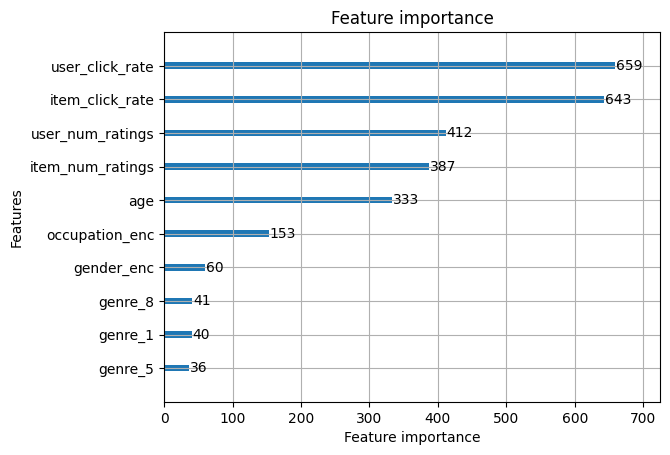

In [38]:
import matplotlib.pyplot as plt

# plot the importance of each feature
lgbm.plot_importance(model, max_num_features=10)
plt.show()